Attacker and Defender strategy simaltaneous optimization

0. Setup
- Operation area's characteristics are globally shared
i.e. map bound, defender's search pattern, static obstacle locations, etc

1. Attacker optimiztaion (Joseph)
- Attacker generates initial guess based on setup

2. Defender optimization (Jeff)
- Defender optimize based on attacker's opitmized path

In [1]:
# Import
import numpy as np
import random as rn
import casadi as ca
import os, json
from scipy.interpolate import splprep, splev
import importlib
import csv
from scipy.interpolate import interp1d
import time

# Import Graphics
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow

# Import Customized python classes
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from Camera import Camera
import Dynamic

importlib.reload(Dynamic)
from Dynamic import DynamicMap

In [2]:
# General Setup of World Parameter
map_size = (50, 50)
num_buildings = 2
num_direc_sensor = 3
num_omni_sensor = 1
num_sensors = num_direc_sensor + num_omni_sensor
fov_half_rad = np.deg2rad(15)
max_range = 25
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
rng_seed = 2

(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot: title={'center': 'Operation Map @ t = 0.00'}>)

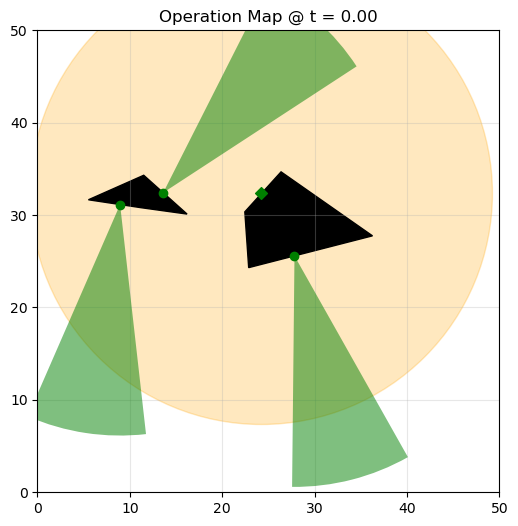

In [3]:
# Generate map
map_in, cam_dict = generate_map(
    map_size= map_size,
    num_buildings= num_buildings,
    num_directional_sensors= num_direc_sensor,
    num_omni_sensors= num_omni_sensor,
    fov_half_rad= fov_half_rad,
    max_range= max_range,
    fov_half_rad_omni= fov_half_rad,
    max_range_omni= max_range/2,
    panspeed_range= panspeed_range,
    cam_period= cam_period,
    cam_increment= cam_increment,
    rng_seed= rng_seed,
    balanced_sensors= False,
    param_lambda= [0.5, 0.5],
    param_beta= [0.4, 0.25]
)

# Parse map_in dictionary
map_size = map_in['st']['size']

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [4]:
# Setup for Attacker Strategy: STP-RRT*
x0 = [0, 0, 0]
xf = [50, 50, 120]
vmax = 5

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json/zero_sum_game", "operation_map.json")
file_path2 = os.path.join("json/zero_sum_game", "defender_info.json")
file_path3 = os.path.join("json/zero_sum_game", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)

In [5]:
print(cam_dict)

{'n': 4, 'n_direc': 3, 'n_omni': 1, 'directional': {'x': array([27.81532552,  8.94032776, 13.60731856]), 'y': array([25.58389372, 31.13996061, 32.42258883]), 'spec': {'init_angle': [-1.3193460480477428, -1.7201224477996322, 0.8403749288260909], 'bound': array([[ 1.48352986, -1.48352986],
       [ 1.48352986, -1.48352986],
       [ 1.48352986, -1.48352986]]), 'fov': [0.2617993877991494, 25.0], 'cam_time': [200, 0.2], 'panspeed': [-0.09213659802020756, -0.13852118572840963, -0.03628251793505524]}}, 'omnidirectional': {'x': array([24.24058021]), 'y': array([32.33650819]), 'spec': {'fov': [0.2617993877991494, 12.5]}}, 'detection': {'directional': {'param_lambda': 0.5, 'param_beta': 0.4}, 'omnidirectional': {'param_lambda': 0.5, 'param_beta': 0.25}}}


In [6]:
print(map_in)

{'st': {'size': array([ 0., 50.,  0., 50.]), 'n': 2, '0': array([[22.44041875, 30.34963863],
       [22.85837455, 24.31154829],
       [36.25649034, 27.75335449],
       [26.36372991, 34.6766209 ]]), '1': array([[ 5.51456295, 31.65636453],
       [11.17162411, 30.80528222],
       [16.18943666, 30.10850332],
       [11.50015324, 34.30858523]])}, 'n': 200, 'ncam': 4}


In [7]:
A = [0, 1, 2, 3, 4]
a = 2
b = len(A) - a
print(A[0:a])
print(A[a:a+b])

[0, 1]
[2, 3, 4]


In [8]:
# Run STP-RRT* Notebook